In [1]:
# Install pandas if not already installed
!pip install pandas  

# Import required libraries
import pandas as pd

Defaulting to user installation because normal site-packages is not writeable


In [4]:
# Load the dataset
df = pd.read_csv("sales_data.csv")

# Display first 5 rows
df.head()

,Order ID,Date,Product Name,Category,Quantity Sold,Price per Unit,Total Sales,Customer Location,Customer Age,Payment Method
0,ORD0001,27-01-2024,Headphones,Electronics,1,44.17,44.17,Phoenix,24,Cash
1,ORD0002,09-03-2024,Table,Furniture,3,307.46,922.38,Chicago,31,Cash
2,ORD0003,29-02-2024,Sneakers,Clothing,3,163.97,491.91,Philadelphia,20,Credit Card
3,ORD0004,27-03-2024,Bread,Grocery,5,454.42,2272.10,Chicago,52,UPI
4,ORD0005,18-03-2024,T-shirt,Clothing,2,18.33,36.66,Phoenix,27,UPI


In [5]:
# Check for missing values
df.isnull().sum()

Order ID             0
Date                 0
Product Name         0
Category             0
Quantity Sold        0
Price per Unit       0
Total Sales          0
Customer Location    0
Customer Age         0
Payment Method       0
dtype: int64

In [7]:
df.ffill(inplace=True)  # Forward fill missing values

In [9]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [11]:
df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")  # Specify the correct format

In [12]:
df.describe()

,Date,Quantity Sold,Price per Unit,Total Sales,Customer Age
count,100,100.000000,100.000000,100.000000,100.000000
mean,2024-02-17 02:52:48,3.090000,256.726300,835.787800,37.760000
min,2024-01-01 00:00:00,1.000000,11.240000,11.240000,18.000000
25%,2024-01-25 18:00:00,2.000000,142.640000,308.947500,29.000000
50%,2024-02-15 00:00:00,3.000000,274.190000,745.165000,36.000000
75%,2024-03-12 00:00:00,4.000000,374.532500,1279.912500,49.000000
max,2024-03-31 00:00:00,5.000000,496.150000,2409.200000,59.000000
std,NaN,1.443166,139.914851,630.935475,12.157319


In [13]:
df.to_csv("cleaned_sales_data.csv", index=False)

In [14]:
df = pd.read_csv("cleaned_sales_data.csv")
df.head()  # Verify the cleaned dataset

,Order ID,Date,Product Name,Category,Quantity Sold,Price per Unit,Total Sales,Customer Location,Customer Age,Payment Method
0,ORD0001,2024-01-27,Headphones,Electronics,1,44.17,44.17,Phoenix,24,Cash
1,ORD0002,2024-03-09,Table,Furniture,3,307.46,922.38,Chicago,31,Cash
2,ORD0003,2024-02-29,Sneakers,Clothing,3,163.97,491.91,Philadelphia,20,Credit Card
3,ORD0004,2024-03-27,Bread,Grocery,5,454.42,2272.10,Chicago,52,UPI
4,ORD0005,2024-03-18,T-shirt,Clothing,2,18.33,36.66,Phoenix,27,UPI


In [15]:
print("Total Sales Revenue:", df["Total Sales"].sum())

Total Sales Revenue: 83578.78


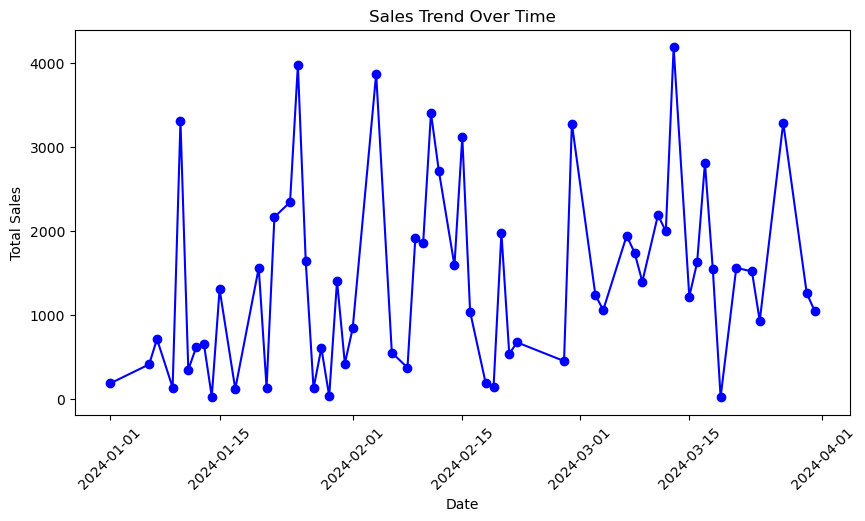

In [16]:
import matplotlib.pyplot as plt  

df["Date"] = pd.to_datetime(df["Date"])  # Ensure Date is in datetime format
sales_trend = df.groupby("Date")["Total Sales"].sum()

plt.figure(figsize=(10,5))
plt.plot(sales_trend, marker="o", linestyle="-", color="b")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Sales Trend Over Time")
plt.xticks(rotation=45)
plt.show()

In [17]:
top_products = df.groupby("Product Name")["Total Sales"].sum().sort_values(ascending=False).head(10)
print(top_products)

Product Name
Laptop        11959.75
Bread          9352.00
Table          8835.56
Milk           7349.83
Lamp           7286.57
T-shirt        7187.61
Smartphone     6615.25
Jeans          6331.54
Headphones     6084.84
Eggs           4812.13
Name: Total Sales, dtype: float64


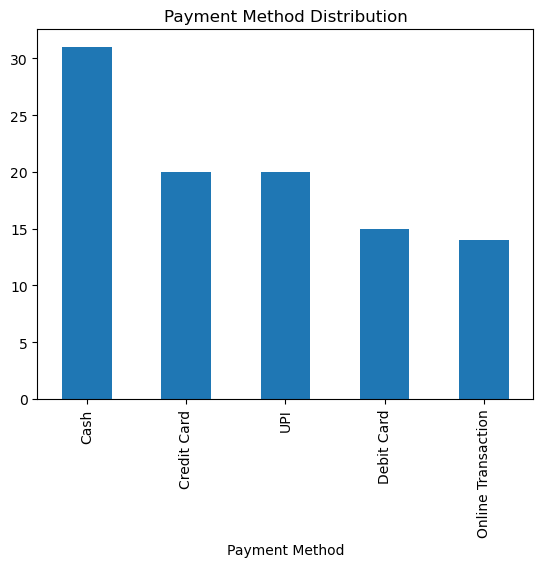

In [18]:
df["Payment Method"].value_counts().plot(kind="bar", title="Payment Method Distribution")
plt.show()

In [20]:
print(df.columns)

Index(['Order ID', 'Date', 'Product Name', 'Category', 'Quantity Sold',
       'Price per Unit', 'Total Sales', 'Customer Location', 'Customer Age',
       'Payment Method'],
      dtype='object')


In [21]:
df.columns = df.columns.str.strip()  # Remove extra spaces

In [24]:
print(df.columns)

Index(['Order ID', 'Date', 'Product Name', 'Category', 'Quantity Sold',
       'Price per Unit', 'Total Sales', 'Customer Location', 'Customer Age',
       'Payment Method'],
      dtype='object')


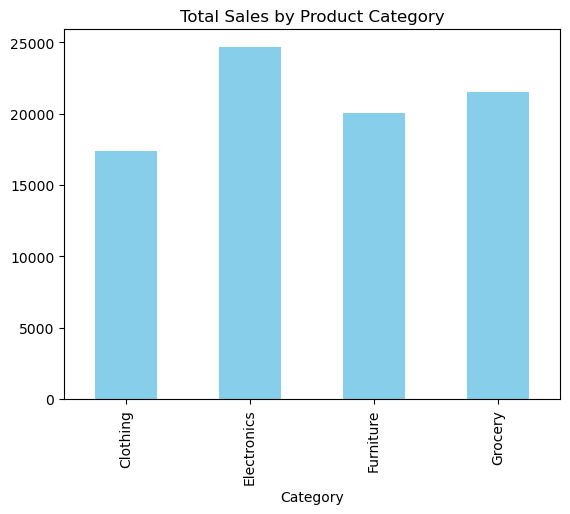

In [25]:
df.groupby("Category")["Total Sales"].sum().plot(kind="bar", title="Total Sales by Product Category", color="skyblue")
plt.show()

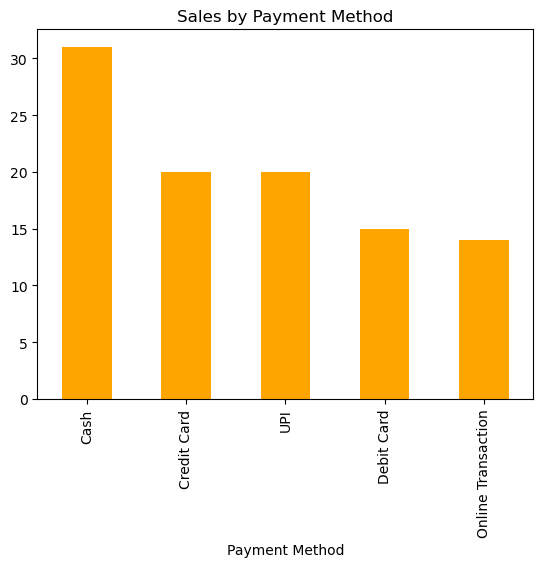

In [26]:
df["Payment Method"].value_counts().plot(kind="bar", title="Sales by Payment Method", color="orange")
plt.show()

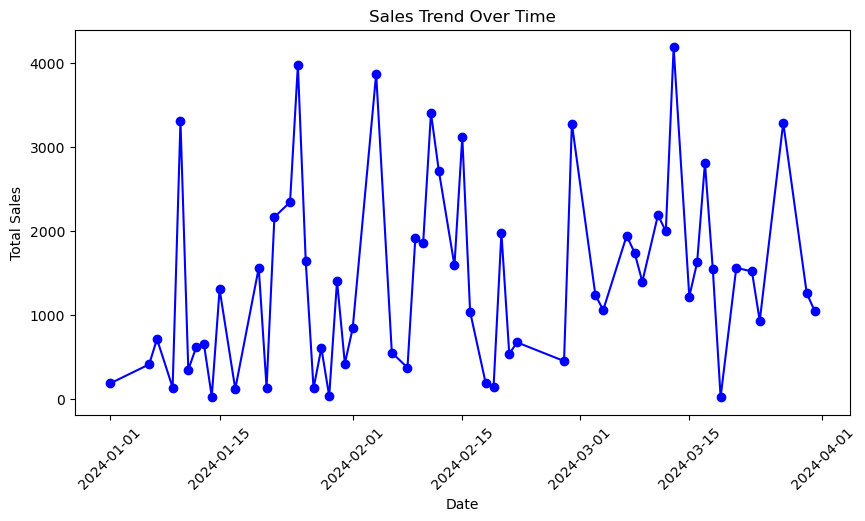

In [27]:
df["Date"] = pd.to_datetime(df["Date"])  
sales_trend = df.groupby("Date")["Total Sales"].sum()

plt.figure(figsize=(10, 5))
plt.plot(sales_trend, marker="o", linestyle="-", color="b")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Sales Trend Over Time")
plt.xticks(rotation=45)
plt.show()

In [29]:
top_locations = df.groupby("Customer Location")["Total Sales"].sum().sort_values(ascending=False)
print(top_locations.head(10))  # Print top 10 locations


Customer Location
Chicago         22151.64
Houston         17748.48
San Antonio     13261.22
Los Angeles      9709.01
Philadelphia     9210.53
New York         8537.31
Phoenix          2960.59
Name: Total Sales, dtype: float64


In [30]:
top_products = df.groupby("Product Name")["Total Sales"].sum().sort_values(ascending=False)
print(top_products.head(10))  # Print top 10 best-selling products

Product Name
Laptop        11959.75
Bread          9352.00
Table          8835.56
Milk           7349.83
Lamp           7286.57
T-shirt        7187.61
Smartphone     6615.25
Jeans          6331.54
Headphones     6084.84
Eggs           4812.13
Name: Total Sales, dtype: float64
